<a href="https://colab.research.google.com/github/jiminmini/mini/blob/ESAA_OB/11_28_%ED%95%84%EC%82%AC_%EA%B3%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**[개념 정리]**

**[LSTM]**
- 순전파: 망각.입력.출력 게이트
- 역전파: 중단 없는 기울기

**[LSTM 셀 구현]**
-  사전에 전처리가 되지 않은 데이터셋의 경우 정확도를 높이기 위해 은닉층의 개수(혹은 뉴런의 개수) 및 하이퍼파라미터 수정 등이 필요


**[LSTM 계층 구현]**
-  결과가 만족스럽지 않다면 하이퍼파라미터에 대한 튜닝도 중요하지만 모델을 변경해 보는 것이 좋음


#**[코드 필사]**

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dataset
from torch.autograd import Variable
from torch.nn import Parameter
from torch import Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
import math

device = torch.device( 'cuda:8' if torch.cuda.is_available() else 'cpu' )
cuda = True if torch.cuda.is_available() else False

Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor

torch.manual_seed(125)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(125)

In [2]:
import torchvision.transforms as transforms
mnist_transform = transforms.Compose([
transforms.ToTensor() ,
transforms.Normalize( (0.5, ), (1.0, ))
])

In [3]:
from torchvision.datasets import MNIST
download_root = '/content/drive/MyDrive/ESAA/11.28/MNIST_DATASET'
train_dataset = MNIST(download_root, transform=mnist_transform, train=True, download=True)
valid_dataset = MNIST( download_root, transform=mnist_transform, train=False, download=True)
test_dataset = MNIST( download_root, transform=mnist_transform, train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 136MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 33.3MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 105MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.98MB/s]


In [4]:
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size,
shuffle=True)
valid_loader = DataLoader(dataset=test_dataset, batch_size=batch_size,
shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size,
shuffle=True)

In [5]:
batch_size=100
n_iters=6000
num_epochs=n_iters/(len(train_dataset)/batch_size)
num_epochs=int(num_epochs)

In [11]:
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size, bias=True):
        super(LSTMCell , self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.bias = bias
        self.x2h = nn.Linear( input_size, 4 * hidden_size, bias=bias)
        self.h2h = nn.Linear( hidden_size, 4 * hidden_size, bias=bias)
        self.reset_parameters()

    def reset_parameters(self):
        std = 1.0 / math.sqrt(self.hidden_size)
        for w in self.parameters():
            w.data.uniform_(-std, std)

    def forward(self, x, hidden):
        hx, cx = hidden
        x = x.view(-1 , x.size(1))

        gates = self.x2h(x) + self.h2h(hx )
        gates= gates.squeeze()
        ingate, forgetgate, cellgate, outgate = gates. chunk (4, 1)

        ingate = F.sigmoid (ingate)
        forgetgate = F.sigmoid (forgetgate)
        cellgate = F.tanh (cellgate)
        outgate = F.sigmoid (outgate)

        cy = torch.mul(cx,forgetgate) + torch.mul(ingate, cellgate)
        hy = torch.mul(outgate, F.tanh(cy))
        return (hy , cy)

In [12]:
class LSTMModel(nn.Module ):
    def __init__(self, input_dim, hidden_dim, layer_dim , output_dim , bias=True ):
        super(LSTMModel , self). __init__()
        self.hidden_dim = hidden_dim

        self.layer_dim = layer_dim
        self.lstm = LSTMCell( input_dim , hidden_dim , layer_dim )
        self.fc = nn.Linear(hidden_dim , output_dim )

    def forward(self, x):
        if torch.cuda.is_available():
            h0 = Variable( torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).cuda())
        else:
            h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim))

        if torch.cuda.is_available():
            c0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).cuda())
        else:
            c0 = Variable(torch.zeros(self.layer_dim, x.size(0),hidden_dim))

        outs=[]
        cn=c0[0,:,:]
        hn=h0[0,:,:]

        for seq in range(x.size(1)):
            hn,cn=self.lstm(x[:, seq, :], (hn,cn))
            outs.append(hn)

        out=outs[-1].squeeze()
        out=self.fc(out)
        return out



In [13]:
input_dim=28
hidden_dim=128
layer_dim=1
output_dim=10

model = LSTMModel( input_dim, hidden_dim, layer_dim, output_dim)
if torch.cuda.is_available():
    model.cuba()
criterion = nn.CrossEntropyLoss()
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters() , lr=learning_rate)

In [17]:
seq_dim = 28
loss_list = []
iter = 0

for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):

        if torch.cuda.is_available():
            images = images.view(-1, seq_dim, input_dim).cuda()
            labels = labels.cuda()
        else:
            images = images.view(-1, seq_dim, input_dim)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        loss_list.append(loss.item())
        iter += 1

        if iter % 500 == 0:
            correct = 0
            total = 0

            for images, labels in valid_loader:
                if torch.cuda.is_available():
                    images = images.view(-1, seq_dim, input_dim).cuda()
                    labels = labels.cuda()
                else:
                    images = images.view(-1, seq_dim, input_dim)

                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()  # cpu() 불필요

            accuracy = 100 * correct / total
            print(f'Iteration: {iter}. Loss: {loss.item():.4f}. Accuracy: {accuracy:.2f}%')


Iteration: 500. Loss: 0.4938. Accuracy: 89.44%
Iteration: 1000. Loss: 0.2320. Accuracy: 92.56%
Iteration: 1500. Loss: 0.1836. Accuracy: 94.82%
Iteration: 2000. Loss: 0.2355. Accuracy: 94.83%
Iteration: 2500. Loss: 0.0233. Accuracy: 96.18%
Iteration: 3000. Loss: 0.0896. Accuracy: 96.77%
Iteration: 3500. Loss: 0.1076. Accuracy: 97.28%
Iteration: 4000. Loss: 0.1106. Accuracy: 97.58%
Iteration: 4500. Loss: 0.1262. Accuracy: 97.48%
Iteration: 5000. Loss: 0.0322. Accuracy: 97.76%
Iteration: 5500. Loss: 0.0659. Accuracy: 97.78%
Iteration: 6000. Loss: 0.0187. Accuracy: 97.94%
Iteration: 6500. Loss: 0.1088. Accuracy: 97.23%
Iteration: 7000. Loss: 0.0371. Accuracy: 97.92%
Iteration: 7500. Loss: 0.0924. Accuracy: 98.03%
Iteration: 8000. Loss: 0.0150. Accuracy: 98.15%
Iteration: 8500. Loss: 0.1477. Accuracy: 97.69%
Iteration: 9000. Loss: 0.0181. Accuracy: 98.13%


In [22]:
def evaluate (model , val_iter) :
    corrects, total, total_loss = 0, 0, 0
    model.eval()
    for images , labels in val_iter:
        if torch.cuda.is_available():
            images = Variable( images. view(-1 , seq_dim, input_dim).cuda())
        else :
            images = Variable( images. view(-1 , seq_dim, input_dim)).to(device)

        logit=model(images).to(device)
        loss = F. cross_entropy (logit , labels , reduction="sum" )
        _, predicted = torch.max(logit . data, 1)
        total += labels.size(0)
        total_loss += loss.item()
        corrects += (predicted == labels).sum()

    avg_loss = total_loss / len (val_iter.dataset)
    avg_accuracy = corrects / tota1
    return avg_loss, avg_accuracy

In [23]:
test_loss , test_acc = evaluate(model, test_loader)
print("Test Loss: %5.2f | Test Accuracy: %5.2f" % (test_loss, test_acc) )

Test Loss:  0.06 | Test Accuracy:   inf


In [25]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch .autograd import Variable
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

device = torch.device( 'cuda:0' if torch.cuda.is_available() else 'cpu' )

In [26]:
data=pd.read_csv('SBUX.csv')
print(data.dtypes)

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


In [33]:
print(data.columns)

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [29]:
data[ 'Date' ] = pd.to_datetime(data[ 'Date'])
data.set_index('Date', inplace=True )

In [34]:
data['Volume'] = data ['Volume'].astype(float)

In [35]:
X = data.iloc[:, :-1]
y = data.iloc[:, 5:6]
print(X)
print(y)

                  Open        High         Low       Close   Adj Close
Date                                                                  
2019-12-11   86.260002   86.870003   85.849998   86.589996   84.145752
2019-12-12   88.000000   88.889999   87.540001   88.209999   85.720032
2019-12-13   88.019997   88.790001   87.580002   88.669998   86.167046
2019-12-16   89.139999   89.300003   88.430000   88.779999   86.273941
2019-12-17   88.870003   88.970001   87.470001   88.129997   85.642288
...                ...         ...         ...         ...         ...
2020-12-04  101.349998  102.940002  101.070000  102.279999  101.442787
2020-12-07  102.010002  102.220001  100.690002  101.410004  100.579918
2020-12-08  100.370003  101.570000  100.010002  101.209999  100.381554
2020-12-09  101.940002  102.209999  100.099998  100.400002   99.578186
2020-12-10  103.510002  106.089996  102.750000  105.389999  104.527336

[253 rows x 5 columns]
                Volume
Date                  
2019-12

In [37]:
ms=MinMaxScaler()
ss=StandardScaler()

X_ss=ss.fit_transform(X)
y_ms=ms.fit_transform(y)

X_train=X_ss[:200, :]
X_test=X_ss[200:,:]

y_train= y_ms[:200,:]
y_test=y_ms[200:,:]

print("Training Shape" , X_train.shape, y_train.shape)
print("Testing Shape" , X_test.shape, y_test.shape)

Training Shape (200, 5) (200, 1)
Testing Shape (53, 5) (53, 1)


In [38]:
X_train_tensors = Variable(torch.Tensor(X_train))
X_test_tensors = Variable(torch.Tensor(X_test))

y_train_tensors = Variable(torch.Tensor(y_train))
y_test_tensors = Variable(torch.Tensor(y_test))

X_train_tensors_f = torch.reshape(X_train_tensors, (X_train_tensors.shape[0], X_train_tensors.shape[1]))
X_test_tensors_f = torch.reshape(X_test_tensors, (X_test_tensors.shape[ 0], X_test_tensors.shape[1]))
print("Training Shape" , X_train_tensors_f.shape, y_train_tensors.shape)
print("Testing Shape" , X_test_tensors_f.shape, y_test_tensors.shape)

Training Shape torch.Size([200, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 5]) torch.Size([53, 1])


In [39]:
class LSTM (nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
        super(LSTM, self).__init__()
        self.num_classes = num_classes
        self.num_layers = num_layers
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.seq_length = seq_length
        self.lstm = nn.LSTM( input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,batch_first=True)
        self.fc_1 = nn.Linear(hidden_size, 128)
        self.fc = nn.Linear(128 , num_classes)
        self.relu = nn.ReLU()

    def forward(self,x):
        h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size))
        c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size))
        output, (hn , cn) = self.lstm(x, (h_0, c_0))
        hn = hn.view ( -1, self. hidden_size)
        out = self.relu(hn )
        out = self.fc_1(out)
        out= self.relu(out)
        out = self.fc(out)
        return out

In [50]:
num_epochs = 1000
learning_rate = 0.0001
input_size = 5
hidden_size = 2
num_layers = 1
num_classes = 1
model = LSTM( num_classes, input_size, hidden_size, num_layers, X_train_tensors_f.shape[1])
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [57]:
print(X_train_tensors_f.shape)
print(X_train_tensors_f.numel())  # 총 요소 수

torch.Size([200, 1, 5])
1000


In [58]:
import torch
import torch.nn as nn
import torch.optim as optim

batch_size, seq_len, input_dim = X_train_tensors_f.shape
hidden_dim = 128
num_layers = 2
output_dim = 1
num_epochs = 1000
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 모델 정의
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # hidden state 초기화
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  # 마지막 타임스텝만 사용
        return out

model = LSTMModel(input_dim, hidden_dim, num_layers, output_dim).to(device)
criterion = nn.MSELoss()  # 회귀 예제 기준
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습
X_train_tensors_f = X_train_tensors_f.to(device)
y_train_tensors = y_train_tensors.to(device)

for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(X_train_tensors_f)
    loss = criterion(outputs, y_train_tensors)
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch: {epoch}, Loss: {loss.item():.5f}")


Epoch: 0, Loss: 0.11972
Epoch: 100, Loss: 0.01789
Epoch: 200, Loss: 0.01571
Epoch: 300, Loss: 0.01180
Epoch: 400, Loss: 0.01067
Epoch: 500, Loss: 0.01044
Epoch: 600, Loss: 0.01028
Epoch: 700, Loss: 0.01014
Epoch: 800, Loss: 0.01002
Epoch: 900, Loss: 0.00990


In [61]:
df_x_ss = ss.transform( data. iloc[ :, :-1])
df_y_ms = ms.transform(data. iloc[ :, -1:])
df_x_ss = Variable(torch.Tensor(df_x_ss))
df_y_ms = Variable(torch.Tensor(df_y_ms))
df_x_ss = torch.reshape(df_x_ss, (df_x_ss.shape[0], 1, df_x_ss.shape[1]))

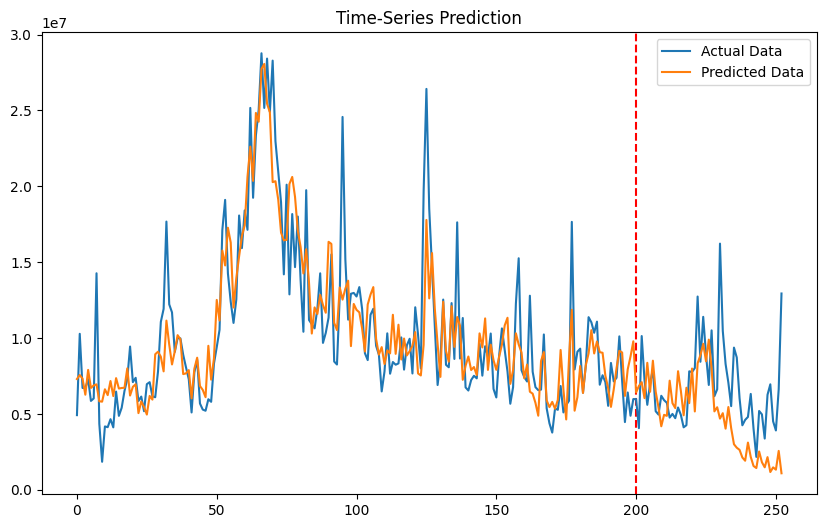

In [62]:
train_predict = model( df_x_ss)
predicted = train_predict.data.numpy()
label_y = df_y_ms.data.numpy()

predicted = ms.inverse_transform( predicted)
label_y = ms.inverse_transform(label_y)
plt.figure( figsize=( 10,6))
plt.axvline(x=200, c= 'r', linestyle= '--' )

plt.plot(label_y, label='Actual Data')
plt.plot(predicted, label='Predicted Data')
plt.title( 'Time-Series Prediction' )
plt.legend()
plt.show()